In [1]:
import os

import rawpy as rp
import exiv2
from src.RawHandler.RawHandler import RawHandler
from src.RawHandler.RawHandlerRawpy import RawHandlerRawpy

import matplotlib.pyplot as plt
from colour_demosaicing import demosaicing_CFA_Bayer_Malvar2004


In [2]:
import rawpy

In [3]:
path = "/Volumes/T7/example_raw/"
files = [path+f for f  in os.listdir(path) if not '._' in f]
files = [f for f in files if not 'xmp' in f]

files

['/Volumes/T7/example_raw/DSCF5760.RAF',
 '/Volumes/T7/example_raw/P1290022.ORF',
 '/Volumes/T7/example_raw/DSC_7584.NEF',
 '/Volumes/T7/example_raw/5M9A0105.CR3',
 '/Volumes/T7/example_raw/DSC00515.ARW',
 '/Volumes/T7/example_raw/IMG_0336.CR2',
 '/Volumes/T7/example_raw/PA176489.ORF',
 '/Volumes/T7/example_raw/P1011751.RW2',
 '/Volumes/T7/example_raw/793A6384.CR2',
 '/Volumes/T7/example_raw/DSC_0029.NEF',
 '/Volumes/T7/example_raw/DSCF5876.RAF',
 '/Volumes/T7/example_raw/DSCF0319.RAF']

In [4]:
# rh = RawHandlerRawpy( '/Volumes/T7/example_raw/DSCF5876.RAF')
colorspace='camera'
# rh = RawHandler( '/Volumes/T7/example_raw/793A6384.CR2', colorspace=colorspace)
rh2 = RawHandlerRawpy('/Volumes/T7/example_raw/793A6384.CR2')

# rh = RawHandler( '/Volumes/EasyStore/RAWNIND/Bayer_TEST_MuseeL-bluebirds-A7C_ISO65535_sha1=2d31480808a4068d0f6c17a9204cb375f35b3a78.arw', colorspace=colorspace)

rh2 = RawHandlerRawpy( '/Volumes/EasyStore/RAWNIND/Bayer_TEST_MuseeL-bluebirds-A7C_ISO65535_sha1=2d31480808a4068d0f6c17a9204cb375f35b3a78.arw')

# rh2 = RawHandlerRawpy( '/Volumes/T7/example_raw/DSCF5760.RAF')
# rh2 = RawHandlerRawpy( '/Volumes/T7/RAWNIND/Bayer_TEST_MuseeL-bluebirds-A7C_ISO125_sha1=4a6064cb0dfffb671c3ee38af56d0751929796bb.arw')
# rh2 = RawHandlerRawpy( '/Volumes/T7/example_raw/DSCF0319.RAF')


#rawforge test_run_baseline.pt /Volumes/EasyStore/test_denoise/Bayer_TEST_MuseeL-bluebirds-A7C_ISO65535_sha1=2d31480808a4068d0f6c17a9204cb375f35b3a78.arw baseline.dng


In [5]:
rh2.to_dng(f"test_resave.dng", uint_img=rh2.rawpy_object.raw_image_visible[0:600, 0:600])

True

In [6]:
img = rh2.rawpy_object.postprocess(
            user_wb=[1, 1, 1, 1],
            output_color=rawpy.ColorSpace.raw,
            demosaic_algorithm= rawpy.DemosaicAlgorithm(3),
            no_auto_bright=True,
            use_camera_wb=False,
            use_auto_wb=False,
            gamma=(1, 1),
            user_flip=0,
            output_bps=16,
            no_auto_scale=True,
        ) / rh2.rawpy_object.white_level
img = img.transpose(2, 0, 1)

In [7]:
img.shape

(3, 4024, 6024)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.1402673503].


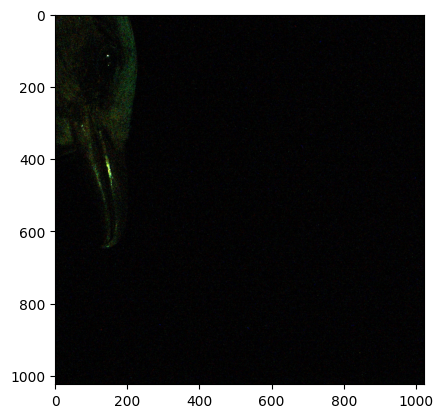

In [8]:
plt.imshow(img[:, 3000:3000+1024,3400:3400+1024].transpose(1, 2, 0)*2)

In [100]:
model_path = "/Volumes/EasyStore/Downloads/test_run_baseline_camera.pt"
model_path = "/Volumes/EasyStore/Downloads/test_run_baseline.pt"
model_path = "/Volumes/EasyStore/Downloads/xtrans_fixed_exposure_599.pt"
model_path = "/Volumes/EasyStore/Downloads/xtrans_fixed_exposure_no_conditioning_400.pt"

import torch

In [101]:
!ls -lrt /Volumes/EasyStore/Downloads/xtrans_*

-rw-r--r--@ 1 ryanmueller  staff  20263407 Jan 21 14:01 /Volumes/EasyStore/Downloads/xtrans_1_100.pt
-rw-r--r--@ 1 ryanmueller  staff  20263445 Jan 21 17:29 /Volumes/EasyStore/Downloads/xtrans_1_300.pt
-rw-r--r--@ 1 ryanmueller  staff  20263445 Jan 21 19:21 /Volumes/EasyStore/Downloads/xtrans_1_400.pt
-rw-r--r--@ 1 ryanmueller  staff  20263317 Jan 21 22:30 /Volumes/EasyStore/Downloads/xtrans_1_599.pt
-rw-r--r--@ 1 ryanmueller  staff  20266989 Jan 22 00:02 /Volumes/EasyStore/Downloads/xtrans_1_only_100.pt
-rw-r--r--@ 1 ryanmueller  staff  20267743 Jan 22 09:42 /Volumes/EasyStore/Downloads/xtrans_1_only_599.pt
-rw-r--r--@ 1 ryanmueller  staff  20271091 Jan 22 12:30 /Volumes/EasyStore/Downloads/xtrans_data_test_old_100.pt
-rw-r--r--@ 1 ryanmueller  staff  20272191 Jan 22 14:05 /Volumes/EasyStore/Downloads/xtrans_data_test_200.pt
-rw-r--r--@ 1 ryanmueller  staff  20272229 Jan 22 14:26 /Volumes/EasyStore/Downloads/xtrans_data_test_300.pt
-rw-r--r--@ 1 ryanmueller  staff  20271141 Jan 22 18:

In [102]:
loaded = torch.jit.load(model_path, map_location='cpu')

In [103]:
model = loaded.eval().to('mps')

In [104]:
x = 1000
y = 3000
x = 2598
y = 3000

# x = 3000
# y = 3400
# x = 0
# y = 0
size = 1020
name = "/Volumes/EasyStore/Downloads/xtrans_fixed_exposure_no_conditioning_400.dng"


_img = img[:, x:x+size, y:y+size]

_img = torch.tensor(_img).float().to('mps').unsqueeze(0).to('mps')
conditioning = torch.tensor([[rh2.full_metadata.get_ISO()]]).to('mps')/6400
_, mask = rh2.compute_mask_and_sparse(dims=(x, size+x, y, size+y))
mask = torch.tensor(mask).bool().to('mps').unsqueeze(0).to('mps')

conditioning = torch.tensor([[65535]]).to('mps')/6400*1
conditioning = torch.tensor([[1]]).to('mps')*0.

In [105]:
rh2.to_dng(f"{name}", uint_img=rh2.rawpy_object.raw_image_visible[x:x+size, y:y+size])

True

In [106]:
rh2.full_metadata.get_ISO()

204800.0

In [107]:
with torch.no_grad():
    cfa = model(_img, conditioning)

In [108]:
def energy_match_blend(img, denoised, alpha=0.5, eps=1e-6):
    # Calculate magnitudes
    img_mag = torch.linalg.norm(img, dim=1, keepdim=True)
    denoised_mag = torch.linalg.norm(denoised, dim=1, keepdim=True)
    
    # Target magnitude is a blend of the two
    target_mag = (1 - alpha.view(-1, 1, 1, 1)) * denoised_mag + alpha.view(-1, 1, 1, 1) * img_mag
    
    # Re-scale the denoised direction to the target magnitude
    return denoised * (target_mag / (denoised_mag + eps))

In [109]:
# cfa = energy_match_blend(_img, cfa, alpha=torch.tensor([[0]]).to('mps'))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.86653].


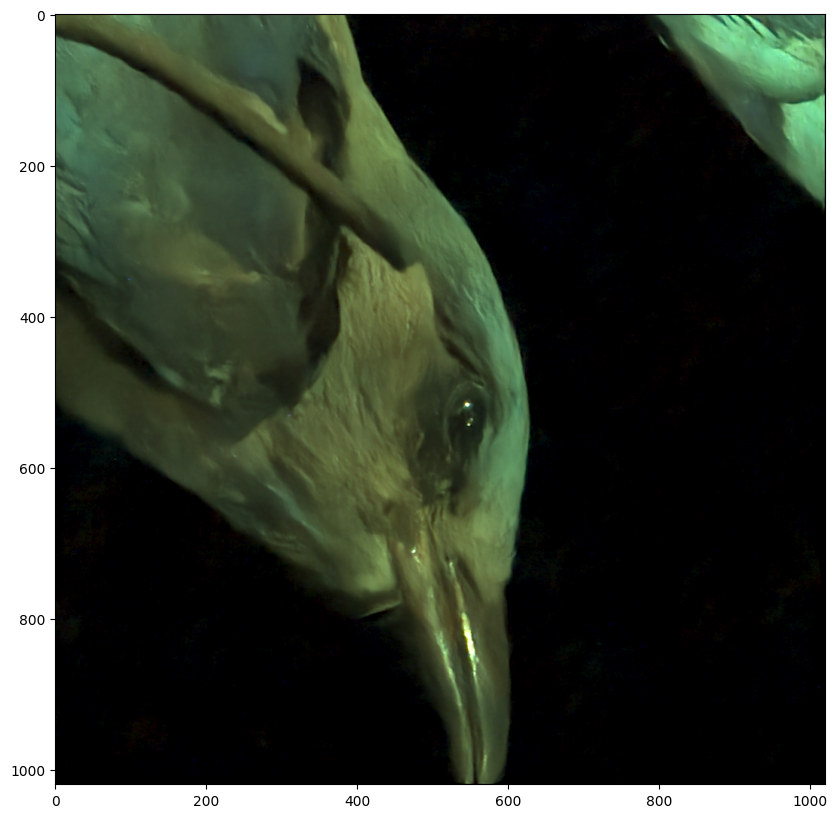

In [110]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(cfa.cpu()[0].permute(1, 2, 0)**.5*2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0560412..1.48181].


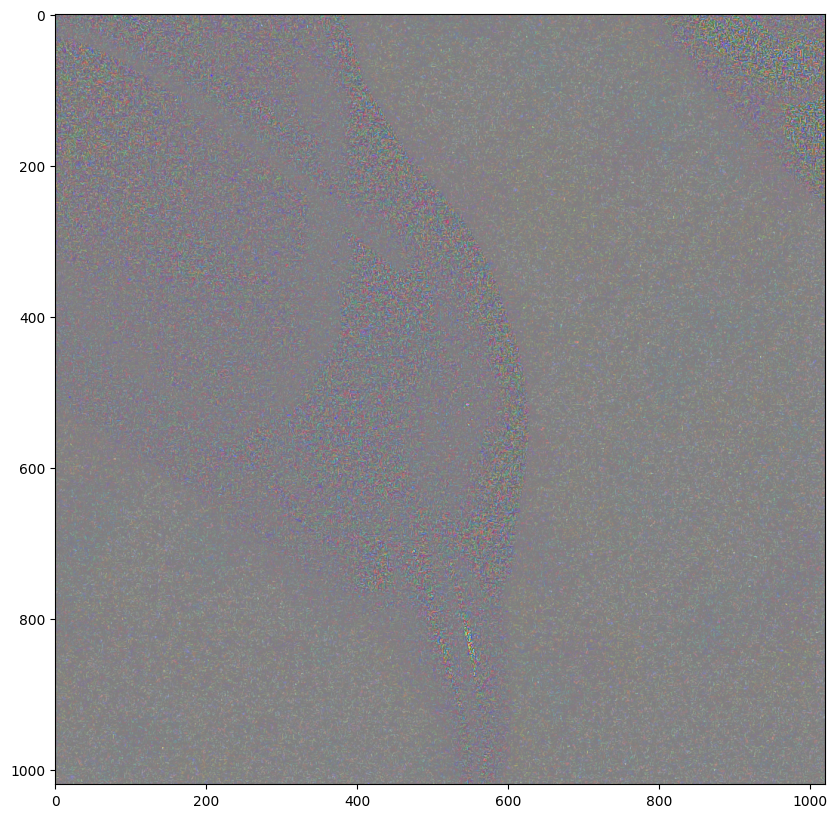

In [73]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow((_img-cfa).cpu()[0].permute(1, 2, 0)*4+0.5)

In [74]:
# rgb_transform = rh.rgb_colorspace_transform()
# import numpy as np
# inv = np.linalg.inv(rgb_transform)

In [75]:
cfa = cfa[0].cpu().numpy()

In [76]:
# inv = np.linalg.inv(rh.rgb_colorspace_transform())
# inv

In [77]:

# orig_dims = cfa.shape
# cfa = (inv @ cfa.reshape(3, -1)).reshape(orig_dims)


In [78]:
cfa = cfa.clip(0, 1)

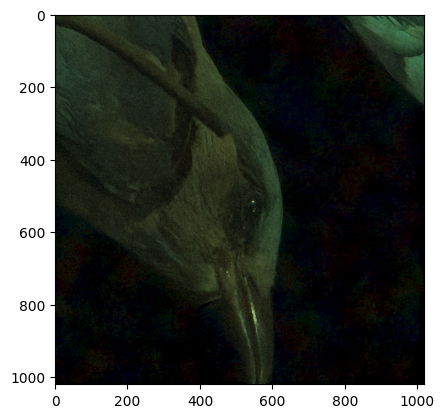

In [79]:
plt.imshow(cfa.transpose(1, 2, 0)**.5)

In [80]:
cfa.shape, mask.shape

((3, 1020, 1020), torch.Size([1, 3, 1020, 1020]))

In [81]:
cfa[~mask[0].cpu().numpy()] = 0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.92112].


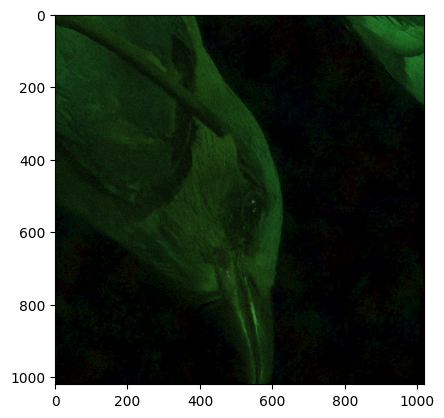

In [82]:
plt.imshow(cfa.transpose(1, 2, 0)**.5*2)

In [83]:
cfa = cfa.sum(axis=0)
# org_cfa = sparse[0].sum(axis=0).cpu().numpy()

In [84]:
rh2.core_metadata.black_level_per_channel[0], rh2.core_metadata.white_level

(1024, 16383)

In [85]:
cfa = cfa * ( rh2.core_metadata.white_level) + rh2.core_metadata.black_level_per_channel[0]

In [86]:
cfa.mean()

1227.2214

In [87]:
rh2.core_metadata.black_level_per_channel[0]

1024

In [88]:
rh2.rawpy_object.black_level_per_channel

[1024, 1024, 1024, 1024]

In [89]:
cfa.shape

(1020, 1020)

In [90]:
rh2.to_dng(f"denoise{name}", uint_img=cfa, user_black_level=0)

True

In [ ]:
rp = rawpy.imread("denoise{name}")

In [ ]:
rp.raw_image_visible

In [ ]:
rp.black_level_per_channel

In [ ]:
rh2.core_metadata.black_level_per_channel[0]

In [ ]:
org_cfa *= rh.core_metadata.white_level
rh.to_dng(f"{name}", uint_img=org_cfa)

In [ ]:
from debayer import Debayer5x5
from debayer import Layout

In [ ]:
f = Debayer5x5(layout=Layout.RGGB).to('mps')

In [ ]:
cfa = torch.tensor(cfa).unsqueeze(0).unsqueeze(0).to('mps')/rh.core_metadata.white_level
org_cfa = torch.tensor(org_cfa).unsqueeze(0).unsqueeze(0).to('mps')/rh.core_metadata.white_level

In [ ]:
cfa.shape

In [ ]:
cfa2 = torch.cat([cfa, org_cfa], axis=0)
cfa2.shape

In [ ]:
output = f(cfa2)

In [ ]:
rh.core_metadata.black_level_per_channel[0]

In [ ]:
output[0].mean(), output[1].mean()

In [ ]:
plt.imshow((output[0]-output[1]).cpu().permute(1,2,0)+0.5)

In [ ]:
plt.imshow(output[0].cpu().permute(1,2,0)**.5*2)

In [ ]:
plt.imshow(output[1].cpu().permute(1,2,0)**.5*2)